In [1]:
import pandas as pd
df_clean = pd.read_pickle('../data/cleaned_loans.pkl')
print(df_clean.shape)

(1342552, 98)


In [2]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

scorecard_features = ['int_rate', 'dti', 'loan_amnt', 'log_annual_inc']
woe_cols = [c + '_woe' for c in scorecard_features]
df_clean[woe_cols] = df_clean[woe_cols].astype(float)

X = df_clean[woe_cols]
y = df_clean['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb_final = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100, max_depth=4)
xgb_final.fit(X_train, y_train)

pd_test = xgb_final.predict_proba(X_test)[:, 1]
print("Model trained. Test set size:", X_test.shape)

Model trained. Test set size: (268511, 4)


In [3]:
from scipy.stats import ks_2samp

pd_defaults = pd_test[y_test.values == 1]
pd_nondefaults = pd_test[y_test.values == 0]

ks_stat, ks_pvalue = ks_2samp(pd_defaults, pd_nondefaults)
print(f"KS statistic: {ks_stat:.4f}")
print(f"As a 0-100 scale: {ks_stat*100:.1f}")

KS statistic: 0.2754
As a 0-100 scale: 27.5


In [4]:
import numpy as np

defaults = df_clean[df_clean['default'] == 1].copy()

defaults['EAD'] = defaults['funded_amnt'] - defaults['total_rec_prncp']
defaults['net_recovery'] = defaults['recoveries'] - defaults['collection_recovery_fee']

defaults['LGD'] = np.where(
    defaults['EAD'] > 0,
    1 - (defaults['net_recovery'] / defaults['EAD']),
    np.nan
)
defaults['LGD'] = defaults['LGD'].clip(0, 1)

print(defaults[['EAD', 'net_recovery', 'LGD']].describe())

                 EAD   net_recovery            LGD
count  266273.000000  266273.000000  266251.000000
mean    11123.526238    1005.380241       0.908608
std      7724.733109    1525.332670       0.110544
min         0.000000       0.000000       0.000000
25%      4993.470000       0.000000       0.880531
50%      9467.210000     492.721600       0.915417
75%     15521.800000    1435.697000       1.000000
max     40000.000000   39397.805600       1.000000


In [5]:
portfolio_lgd = defaults['LGD'].mean()
ead_test = df_clean.loc[X_test.index, 'funded_amnt']

expected_loss = pd_test * portfolio_lgd * ead_test

print(f"Average LGD used: {portfolio_lgd:.4f}")
print(f"Total exposure (EAD) in test set: ₹{ead_test.sum():,.0f}")
print(f"Total Expected Loss: ₹{expected_loss.sum():,.0f}")
print(f"Expected Loss as % of exposure: {expected_loss.sum() / ead_test.sum() * 100:.2f}%")

Average LGD used: 0.9086
Total exposure (EAD) in test set: ₹3,866,214,600
Total Expected Loss: ₹748,786,865
Expected Loss as % of exposure: 19.37%


In [6]:
base_score = 600
base_odds = 50
pdo = 20

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

print(f"Factor: {factor:.4f}")
print(f"Offset: {offset:.4f}")

Factor: 28.8539
Offset: 487.1229


In [8]:
import numpy as np

def calculate_woe_iv(df, feature, target, bins=10):
    data = df[[feature, target]].copy()
    data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')

    grouped = data.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad

    eps = 1e-6
    grouped['woe'] = np.log((grouped['good_pct'] + eps) / (grouped['bad_pct'] + eps))
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']

    total_iv = grouped['iv'].sum()
    return grouped, total_iv

In [9]:
woe_tables = {}
scorecard_points = {}

for col in scorecard_features:
    woe_tab, _ = calculate_woe_iv(df_clean, col, 'default', bins=10)
    woe_tables[col] = woe_tab
    points = (woe_tab['woe'] * factor).round(0).astype(int)
    scorecard_points[col] = points
    print(f"\n=== {col} points by bin ===")
    print(points)

C:\Users\91703\AppData\Local\Temp\ipykernel_25504\1816018011.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])



=== int_rate points by bin ===
bin
(5.308999999999999, 7.39]    46
(7.39, 8.9]                  28
(8.9, 10.49]                 17
(10.49, 11.53]                9
(11.53, 12.74]                5
(12.74, 13.98]                0
(13.98, 15.22]               -6
(15.22, 16.99]              -11
(16.99, 19.47]              -18
(19.47, 30.99]              -28
Name: woe, dtype: int64


C:\Users\91703\AppData\Local\Temp\ipykernel_25504\1816018011.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])



=== dti points by bin ===
bin
(-0.001, 7.28]     11
(7.28, 10.49]       9
(10.49, 13.02]      7
(13.02, 15.324]     5
(15.324, 17.61]     3
(17.61, 19.98]      0
(19.98, 22.59]     -2
(22.59, 25.68]     -5
(25.68, 29.76]     -9
(29.76, 100.0]    -14
Name: woe, dtype: int64


C:\Users\91703\AppData\Local\Temp\ipykernel_25504\1816018011.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\91703\AppData\Local\Temp\ipykernel_25504\1816018011.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])



=== loan_amnt points by bin ===
bin
(499.999, 5000.0]     8
(5000.0, 6500.0]      8
(6500.0, 8675.0]      6
(8675.0, 10000.0]     3
(10000.0, 12000.0]   -1
(12000.0, 15000.0]   -2
(15000.0, 18000.0]   -5
(18000.0, 21000.0]   -5
(21000.0, 28000.0]   -4
(28000.0, 40000.0]   -7
Name: woe, dtype: int64

=== log_annual_inc points by bin ===
bin
(6.0649999999999995, 10.434]    -7
(10.434, 10.645]                -5
(10.645, 10.82]                 -3
(10.82, 10.951]                 -2
(10.951, 11.082]                -2
(11.082, 11.212]                 1
(11.212, 11.35]                  2
(11.35, 11.513]                  4
(11.513, 11.736]                 7
(11.736, 16.213]                10
Name: woe, dtype: int64


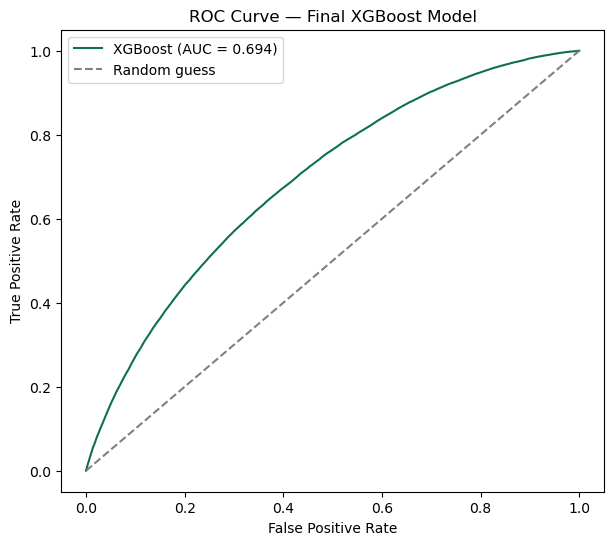

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import os

os.makedirs('../figures', exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, pd_test)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label='XGBoost (AUC = 0.694)', color='#0F6E56')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final XGBoost Model'); plt.legend()
plt.savefig('../figures/roc_curve.png', dpi=150)
plt.show()